In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pump-sensor-data/sensor.csv


In [1]:
import pandas as pd
df =  pd.read_csv("sensor.csv")

In [2]:
df.head()

,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [3]:
df = df.drop(columns=['Unnamed: 0'])


In [4]:
len(df)

220320

In [5]:
rows_with_zero_or_nan = df.applymap(lambda x: pd.isna(x) ).any(axis=1)  # adding this not changing anything 'or x == 0'
count = rows_with_zero_or_nan.sum()
print(f"Number of rows with at least one 0 or NaN value: {count}")

C:\Users\mozah\AppData\Local\Temp\ipykernel_21044\2342891805.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  rows_with_zero_or_nan = df.applymap(lambda x: pd.isna(x) ).any(axis=1)  # adding this not changing anything 'or x == 0'


Number of rows with at least one 0 or NaN value: 220320


In [6]:
df.head()

,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [7]:
print(df.isnull().sum())

timestamp              0
sensor_00          10208
sensor_01            369
sensor_02             19
sensor_03             19
sensor_04             19
sensor_05             19
sensor_06           4798
sensor_07           5451
sensor_08           5107
sensor_09           4595
sensor_10             19
sensor_11             19
sensor_12             19
sensor_13             19
sensor_14             21
sensor_15         220320
sensor_16             31
sensor_17             46
sensor_18             46
sensor_19             16
sensor_20             16
sensor_21             16
sensor_22             41
sensor_23             16
sensor_24             16
sensor_25             36
sensor_26             20
sensor_27             16
sensor_28             16
sensor_29             72
sensor_30            261
sensor_31             16
sensor_32             68
sensor_33             16
sensor_34             16
sensor_35             16
sensor_36             16
sensor_37             16
sensor_38             27


In [8]:
# Drop sensors with excessive missing values
sensors_to_drop = ['sensor_15', 'sensor_50']
df = df.drop(columns=sensors_to_drop)


# Maybe KNN for filling data could be better maybe later will check

In [9]:
sensor_cols = df.columns[df.isnull().any()].tolist()

print("Columns with at least one NaN value:")
print(sensor_cols)

Columns with at least one NaN value:
['sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41', 'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47', 'sensor_48', 'sensor_49', 'sensor_51']


In [10]:
# Linear interpolation
df[sensor_cols] = df[sensor_cols].interpolate(method='linear')

# If any remaining NaNs, use forward/backward fill
df[sensor_cols] = df[sensor_cols].fillna(method='ffill')
df[sensor_cols] = df[sensor_cols].fillna(method='bfill')
# Verify no missing values remain
print(df[sensor_cols].isnull().sum())

C:\Users\mozah\AppData\Local\Temp\ipykernel_21044\784687372.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[sensor_cols] = df[sensor_cols].fillna(method='ffill')
C:\Users\mozah\AppData\Local\Temp\ipykernel_21044\784687372.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[sensor_cols] = df[sensor_cols].fillna(method='bfill')


sensor_00    0
sensor_01    0
sensor_02    0
sensor_03    0
sensor_04    0
sensor_05    0
sensor_06    0
sensor_07    0
sensor_08    0
sensor_09    0
sensor_10    0
sensor_11    0
sensor_12    0
sensor_13    0
sensor_14    0
sensor_16    0
sensor_17    0
sensor_18    0
sensor_19    0
sensor_20    0
sensor_21    0
sensor_22    0
sensor_23    0
sensor_24    0
sensor_25    0
sensor_26    0
sensor_27    0
sensor_28    0
sensor_29    0
sensor_30    0
sensor_31    0
sensor_32    0
sensor_33    0
sensor_34    0
sensor_35    0
sensor_36    0
sensor_37    0
sensor_38    0
sensor_39    0
sensor_40    0
sensor_41    0
sensor_42    0
sensor_43    0
sensor_44    0
sensor_45    0
sensor_46    0
sensor_47    0
sensor_48    0
sensor_49    0
sensor_51    0
dtype: int64


In [11]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Encode machine_status if necessary
df['machine_status'] = df['machine_status'].map({'NORMAL': 0, 'BROKEN': 1, 'RECOVERING': 2})


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 52 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   timestamp       220320 non-null  datetime64[ns]
 1   sensor_00       220320 non-null  float64       
 2   sensor_01       220320 non-null  float64       
 3   sensor_02       220320 non-null  float64       
 4   sensor_03       220320 non-null  float64       
 5   sensor_04       220320 non-null  float64       
 6   sensor_05       220320 non-null  float64       
 7   sensor_06       220320 non-null  float64       
 8   sensor_07       220320 non-null  float64       
 9   sensor_08       220320 non-null  float64       
 10  sensor_09       220320 non-null  float64       
 11  sensor_10       220320 non-null  float64       
 12  sensor_11       220320 non-null  float64       
 13  sensor_12       220320 non-null  float64       
 14  sensor_13       220320 non-null  flo

# I will scale the shit out of my sensors

In [13]:
from sklearn.preprocessing import StandardScaler

# Select sensor columns
sensor_cols = [col for col in df.columns if 'sensor_' in col]

# Scale sensor data using StandardScaler
scaler = StandardScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])


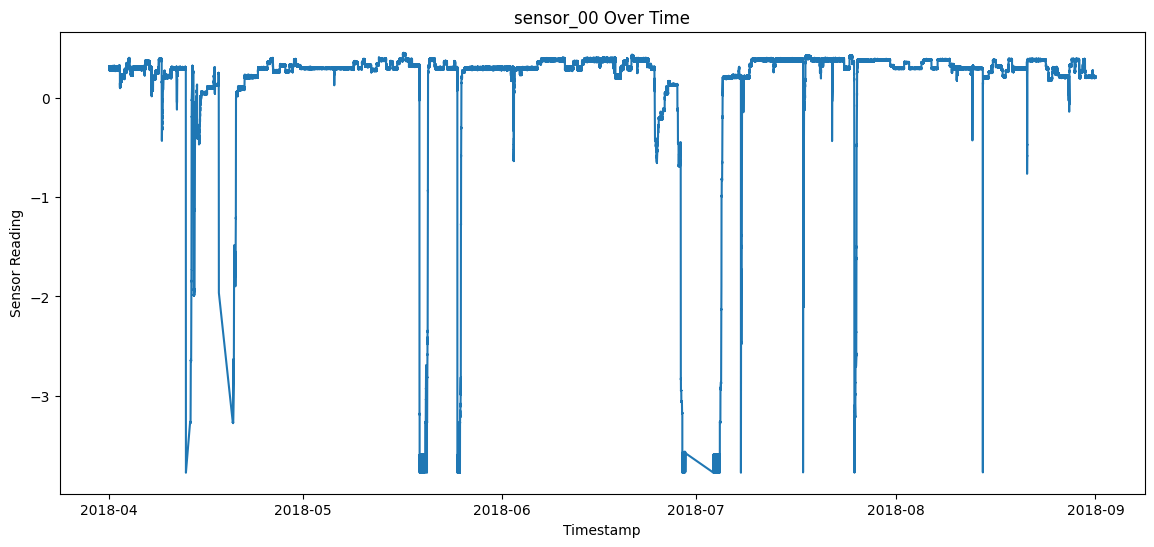

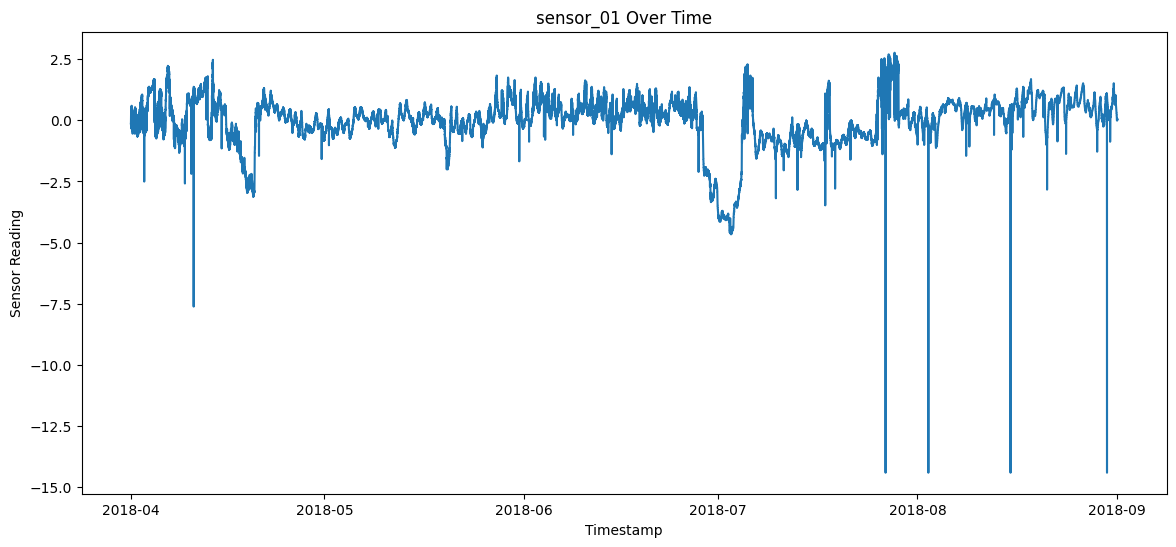

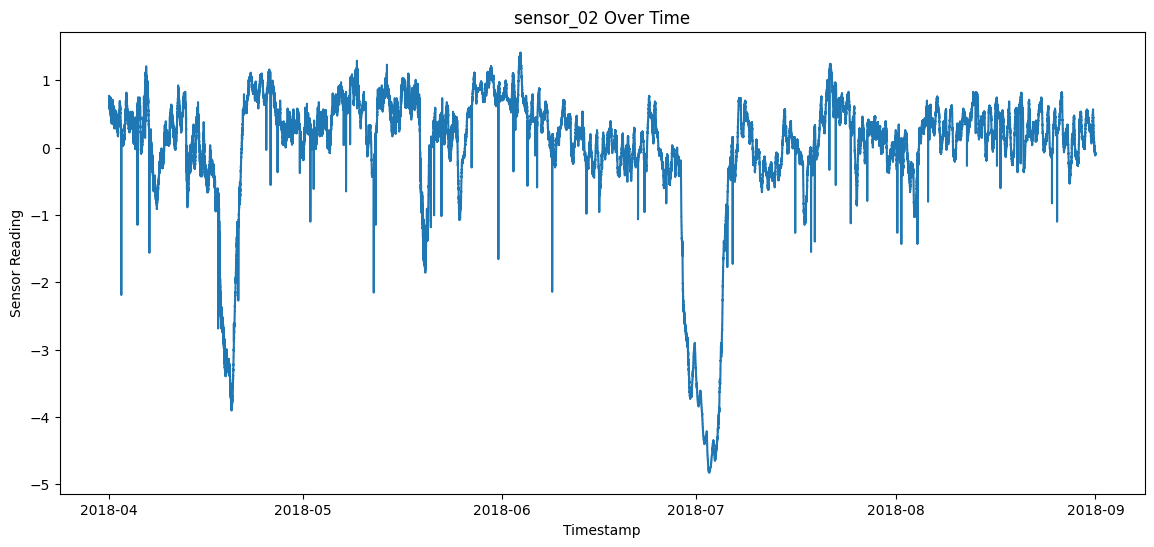

In [14]:
import matplotlib.pyplot as plt

# Plot sensor readings over time for a few sensors
for col in sensor_cols[:3]:
    plt.figure(figsize=(14, 6))
    plt.plot(df['timestamp'], df[col])
    plt.title(f'{col} Over Time')
    plt.xlabel('Timestamp')
    plt.ylabel('Sensor Reading')
    plt.show()


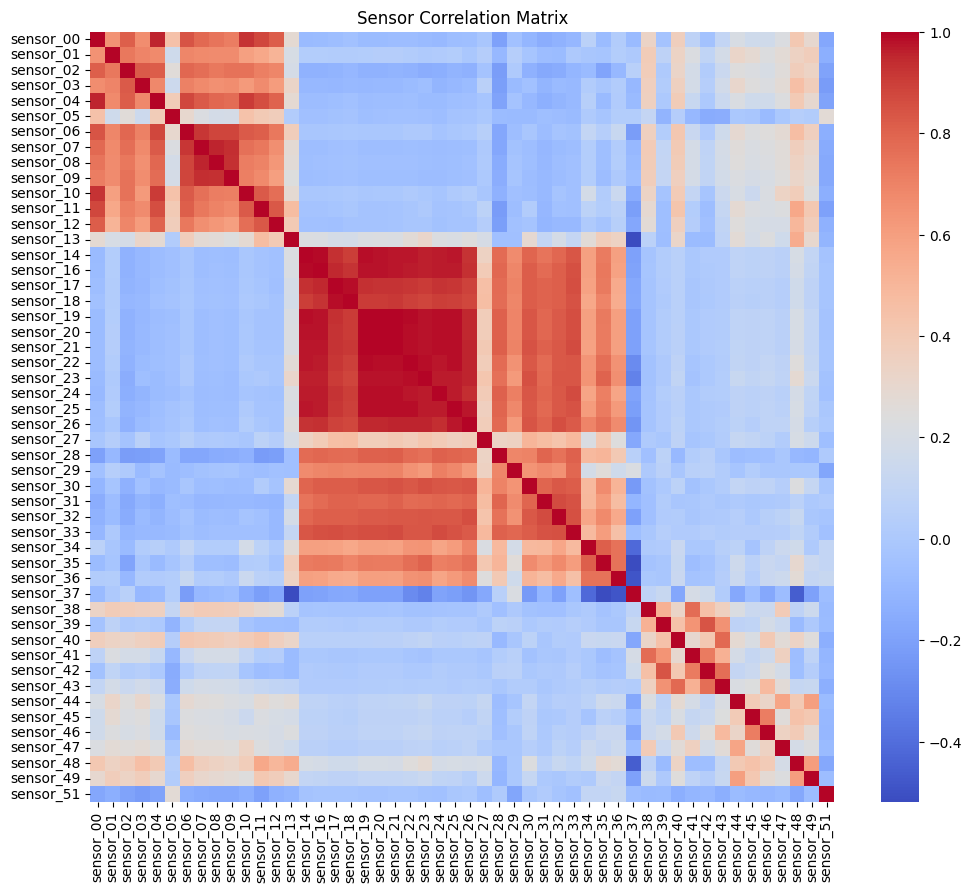

In [16]:
import seaborn as sns

# Compute correlation matrix
corr_matrix = df[sensor_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Sensor Correlation Matrix')
plt.show()


In [17]:
# Extract time-based features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month


In [18]:
from sklearn.decomposition import PCA

# Apply PCA to sensor data
pca = PCA(n_components=0.99)  # Retain 95% of variance
sensor_data_pca = pca.fit_transform(df[sensor_cols])

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
print(f'Number of components selected: {pca.n_components_}')
print(f'Explained variance ratio: {sum(explained_variance)}')


Number of components selected: 34
Explained variance ratio: 0.9909044893018059


In [19]:
# Reconstruct sensor data from PCA components
sensor_data_reconstructed = pca.inverse_transform(sensor_data_pca)

# Calculate reconstruction error
reconstruction_error = ((df[sensor_cols] - sensor_data_reconstructed) ** 2).mean(axis=1)

# Add reconstruction error to DataFrame
df['reconstruction_error'] = reconstruction_error

# Set anomaly threshold (e.g., 95th percentile)
threshold = df['reconstruction_error'].quantile(0.999)

# Flag anomalies
df['anomaly'] = df['reconstruction_error'] > threshold


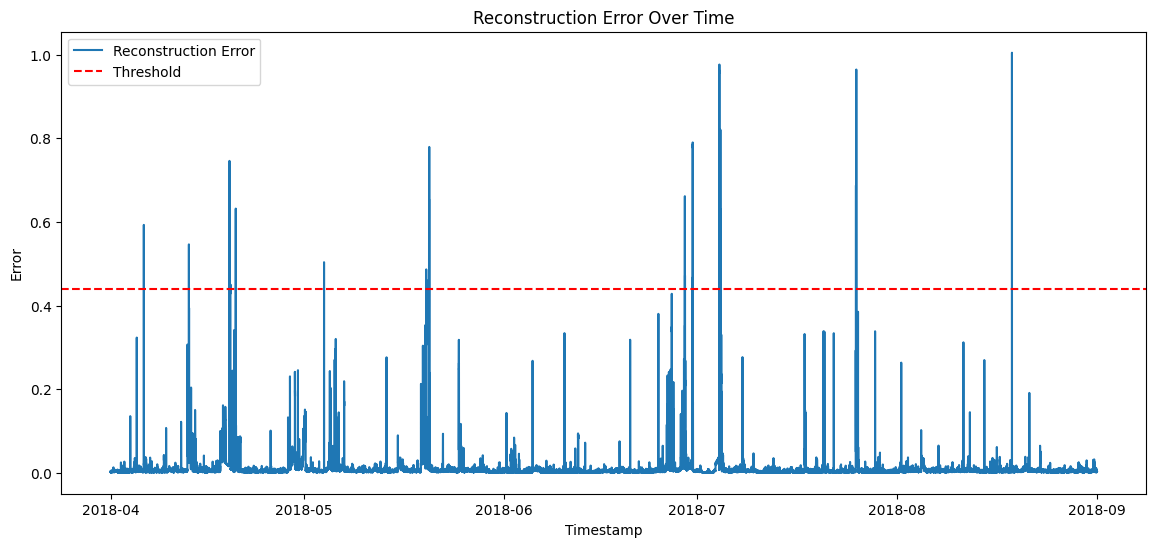

In [20]:
plt.figure(figsize=(14, 6))
plt.plot(df['timestamp'], df['reconstruction_error'], label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.title('Reconstruction Error Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Error')
plt.legend()
plt.show()


In [21]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = len(sensor_cols)
encoding_dim = int(input_dim / 2)

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation='relu')(input_layer)
decoder = Dense(input_dim, activation='sigmoid')(encoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,575 (10.06 KB)

 Trainable params: 2,575 (10.06 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Prepare data
X = df[sensor_cols].values

# Train model
autoencoder.fit(X, X, epochs=50, batch_size=64, shuffle=True, validation_split=0.1)


Epoch 1/50
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.8721 - val_loss: 0.3010
Epoch 2/50
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.8352 - val_loss: 0.2863
Epoch 3/50
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.8315 - val_loss: 0.2818
Epoch 4/50
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.8303 - val_loss: 0.2807
Epoch 5/50
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.8296 - val_loss: 0.2799
Epoch 6/50
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.8291 - val_loss: 0.2785
Epoch 7/50
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.8287 - val_loss: 0.2785
Epoch 8/50
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.8283 - val_loss: 0.2778
Epoch 9/50
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.8281 - val_loss: 0.2768
Epoch 10/50
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.8279 - val_loss: 0.2769
Epoch 11/50
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.8278 - val_loss: 0.2766
Epoch 12/50
3099/3099 ━━━━━━━━

In [25]:
import numpy as np 
# Reconstruct data
X_pred = autoencoder.predict(X)

# Calculate reconstruction error
mse = np.mean(np.power(X - X_pred, 2), axis=1)
df['reconstruction_error'] = mse

# Set threshold
threshold = np.percentile(mse, 99.9)
df['anomaly'] = df['reconstruction_error'] > threshold


6885/6885 ━━━━━━━━━━━━━━━━━━━━ 4s 547us/step


In [26]:
df['anomaly'].value_counts()

anomaly
False    220099
True        221
Name: count, dtype: int64

In [28]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np

# Prepare data
X = df[sensor_cols]
y = df['machine_status']

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Map encoded classes for clarity
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class Mapping:", class_mapping)

# Check class distribution
unique, counts = np.unique(y_encoded, return_counts=True)
class_distribution = dict(zip(unique, counts))
print("Original Class Distribution:", class_distribution)

# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# Recalculate class distribution in y_train
unique_train, counts_train = np.unique(y_train, return_counts=True)
class_distribution_train = dict(zip(unique_train, counts_train))
print("Training Set Class Distribution:", class_distribution_train)

# Determine the minimum number of samples in the minority classes
minority_class_counts = min(counts_train)
print("Minimum samples in minority class:", minority_class_counts)

# Adjust k_neighbors based on minority class samples
k_neighbors = min(5, minority_class_counts - 1)
if k_neighbors < 1:
    k_neighbors = 1  # Set to minimum valid value

print("Adjusted k_neighbors for SMOTE in SMOTEENN:", k_neighbors)

# Create SMOTE instance with adjusted k_neighbors
smote = SMOTE(k_neighbors=k_neighbors, random_state=42)

# Combine over-sampling and under-sampling using SMOTEENN
sme = SMOTEENN(smote=smote, random_state=42)
X_train_resampled, y_train_resampled = sme.fit_resample(X_train, y_train)

# Check the new class distribution
unique_resampled, counts_resampled = np.unique(y_train_resampled, return_counts=True)
class_distribution_resampled = dict(zip(unique_resampled, counts_resampled))
print("Resampled Training Set Class Distribution:", class_distribution_resampled)

# Adjust class weights
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_resampled)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_resampled
)
class_weight_dict = dict(zip(classes, class_weights))
print("Class Weights:", class_weight_dict)

# Convert class weights to sample weights
sample_weights = np.array([class_weight_dict[label] for label in y_train_resampled])

# Train model with sample weights
model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

model.fit(
    X_train_resampled,
    y_train_resampled,
    sample_weight=sample_weights
)

# Predictions
y_pred_proba = model.predict_proba(X_test)

# For multi-class classification, adjust thresholds if necessary
# Here, we will not adjust thresholds but proceed with default argmax
y_pred = np.argmax(y_pred_proba, axis=1)

# Convert class labels to strings for target_names
target_names = [str(class_label) for class_label in le.classes_]

# Evaluate
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Check the distribution of true and predicted labels
print("\nTrue labels distribution in y_test:", Counter(y_test))
print("Predicted labels distribution in y_pred:", Counter(y_pred))


Class Mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}
Original Class Distribution: {np.int64(0): np.int64(205836), np.int64(1): np.int64(7), np.int64(2): np.int64(14477)}
Training Set Class Distribution: {np.int64(0): np.int64(164669), np.int64(1): np.int64(5), np.int64(2): np.int64(11582)}
Minimum samples in minority class: 5
Adjusted k_neighbors for SMOTE in SMOTEENN: 4
Resampled Training Set Class Distribution: {np.int64(0): np.int64(164642), np.int64(1): np.int64(164664), np.int64(2): np.int64(164661)}
Class Weights: {np.int64(0): np.float64(1.0000830083858716), np.int64(1): np.float64(0.9999493918929862), np.int64(2): np.float64(0.9999676102214043)}


c:\Users\mozah\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:18:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     41167
           1       0.00      0.00      0.00         2
           2       1.00      1.00      1.00      2895

    accuracy                           1.00     44064
   macro avg       0.67      0.67      0.67     44064
weighted avg       1.00      1.00      1.00     44064


Confusion Matrix:
[[41152     4    11]
 [    2     0     0]
 [    0     0  2895]]

True labels distribution in y_test: Counter({np.int64(0): 41167, np.int64(2): 2895, np.int64(1): 2})
Predicted labels distribution in y_pred: Counter({np.int64(0): 41154, np.int64(2): 2906, np.int64(1): 4})


In [30]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Use default base estimator (DecisionTree with max_depth=1)
model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     41167
           1       0.00      0.00      0.00         2
           2       0.96      0.99      0.97      2895

    accuracy                           1.00     44064
   macro avg       0.65      0.66      0.66     44064
weighted avg       1.00      1.00      1.00     44064


Confusion Matrix:
[[41043     0   124]
 [    2     0     0]
 [   34     0  2861]]


In [31]:
print('a')

a


In [32]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[sensor_cols])

# Generate sequences
sequence_length = 10
generator = TimeseriesGenerator(X_scaled, X_scaled, length=sequence_length, batch_size=32)


In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(sequence_length, len(sensor_cols))))
model.add(Dense(len(sensor_cols)))

model.compile(optimizer='adam', loss='mse')
model.summary()

# Train model
model.fit(generator, epochs=20)


c:\Users\mozah\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         3,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,690 (127.70 KB)

 Trainable params: 32,690 (127.70 KB)

 Non-trainable params: 0 (0.00 B)

c:\Users\mozah\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
6885/6885 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.1947
Epoch 2/20
6885/6885 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0.0739
Epoch 3/20
6885/6885 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0.0577
Epoch 4/20
6885/6885 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0623
Epoch 5/20
6885/6885 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0.0453
Epoch 6/20
6885/6885 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0473
Epoch 7/20
6885/6885 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0448
Epoch 8/20
6885/6885 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0627
Epoch 9/20
6885/6885 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0443
Epoch 10/20
6885/6885 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0341
Epoch 11/20
6885/6885 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0397
Epoch 12/20
6885/6885 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0674
Epoch 13/20
6885/6885 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0412
Epoch 14/20
6885/6885 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0412
Epoch 15/20
688

In [34]:
# Generate predictions
X_pred = model.predict(generator)

# Flatten predictions and true values
X_pred_flat = X_pred.reshape(-1, len(sensor_cols))
X_true_flat = X_scaled[sequence_length:]

# Calculate reconstruction error
mse = np.mean(np.power(X_true_flat - X_pred_flat, 2), axis=1)
df['reconstruction_error'] = np.nan
df.loc[df.index[sequence_length:], 'reconstruction_error'] = mse

# Set threshold
threshold = np.percentile(mse, 99.9)
df['anomaly'] = df['reconstruction_error'] > threshold


6885/6885 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


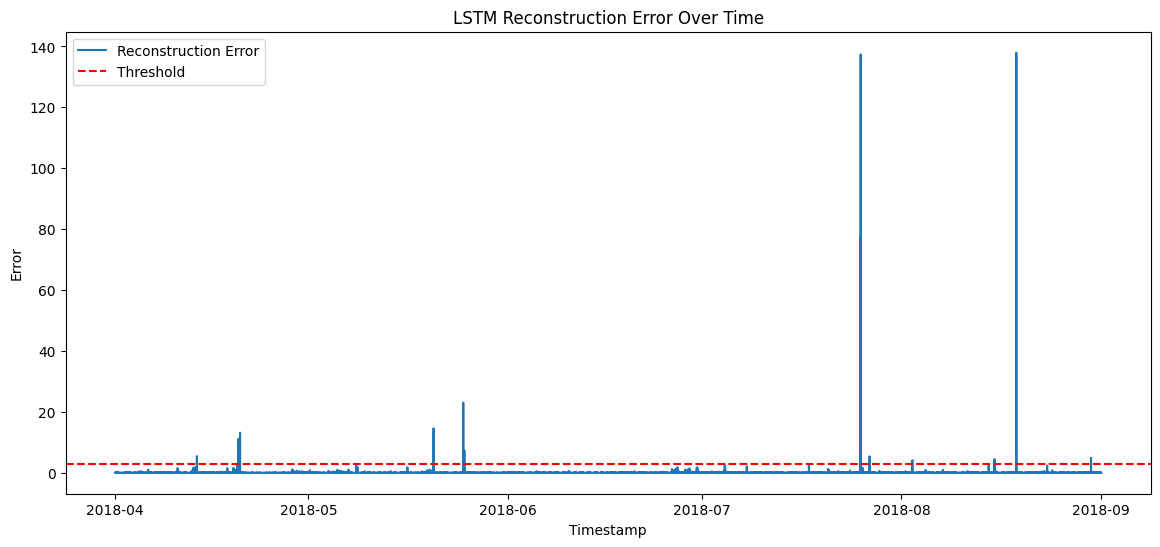

In [35]:
plt.figure(figsize=(14, 6))
plt.plot(df['timestamp'], df['reconstruction_error'], label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.title('LSTM Reconstruction Error Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Error')
plt.legend()
plt.show()


Confusion Matrix:
[[205771     65]
 [ 14328    156]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97    205836
           1       0.71      0.01      0.02     14484

    accuracy                           0.93    220320
   macro avg       0.82      0.51      0.49    220320
weighted avg       0.92      0.93      0.90    220320



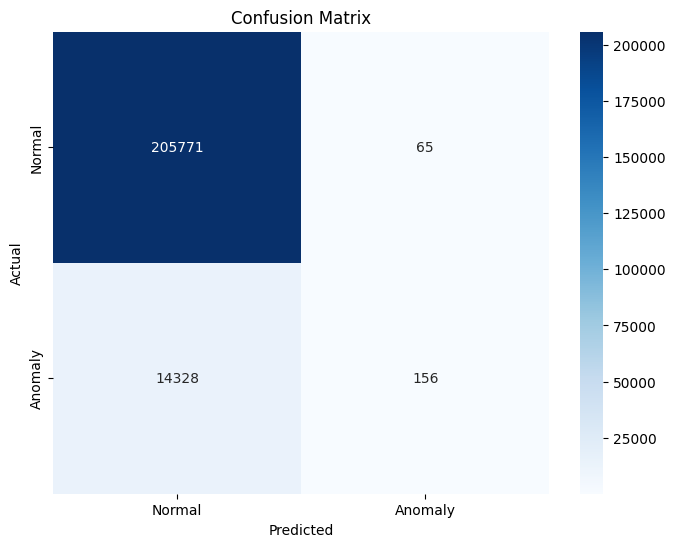

In [36]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure ground truth labels are binary
# Assuming 'machine_status' column exists and maps to NORMAL = 0, BROKEN = 1
y_true = (df['machine_status'] != 0).astype(int)  # Convert to binary (0 = NORMAL, 1 = ANOMALY)

# Predicted labels
y_pred = df['anomaly'].astype(int)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Optional: Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# better lstm


In [37]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix


In [38]:
df['machine_status'].value_counts()

machine_status
0    205836
2     14477
1         7
Name: count, dtype: int64

In [39]:
# Assuming df is your DataFrame and sensor_cols are the sensor columns

# Separate normal and anomaly data
normal_data = df[df['machine_status'] == 0]
anomaly_data = df[df['machine_status'] != 0]  # 'BROKEN' or 'RECOVERING'

print(f"Total normal data: {len(normal_data)}")
print(f"Total anomaly data: {len(anomaly_data)}")


Total normal data: 205836
Total anomaly data: 14484


In [40]:
# Split normal data into training and validation sets
train_size = int(len(normal_data) * 0.8)
normal_train = normal_data.iloc[:train_size]
normal_val = normal_data.iloc[train_size:]

# Use all anomalies in the validation set
anomaly_val = anomaly_data

# Combine validation data
validation_data = pd.concat([normal_val, anomaly_val])

print(f"Training normal data: {len(normal_train)}")
print(f"Validation normal data: {len(normal_val)}")
print(f"Validation anomaly data: {len(anomaly_val)}")
print(f"Total validation data: {len(validation_data)}")


Training normal data: 164668
Validation normal data: 41168
Validation anomaly data: 14484
Total validation data: 55652


In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(normal_train[sensor_cols])
X_val_scaled = scaler.transform(validation_data[sensor_cols])


In [42]:
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        seq = data[i:i+seq_length]
        sequences.append(seq)
    return np.array(sequences)


In [43]:
sequence_length = 10

X_train_seq = create_sequences(X_train_scaled, sequence_length)
X_val_seq = create_sequences(X_val_scaled, sequence_length)

print(f"Training sequences shape: {X_train_seq.shape}")
print(f"Validation sequences shape: {X_val_seq.shape}")


Training sequences shape: (164659, 10, 50)
Validation sequences shape: (55643, 10, 50)


In [44]:
# Get the labels for the validation data
y_val = validation_data['machine_status'].values[sequence_length - 1:]

# Map numeric labels to status names if needed
label_mapping = {0: 'NORMAL', 1: 'BROKEN', 2: 'RECOVERING'}

# Since y_val contains numeric labels, we can use them directly
y_val_labels = y_val  # Already numeric labels

print(f"Validation labels shape: {y_val_labels.shape}")
print("Label distribution in validation data:")

unique, counts = np.unique(y_val_labels, return_counts=True)
label_counts = dict(zip(unique, counts))

for label, count in label_counts.items():
    status = label_mapping[label]
    print(f"{status}: {count}")



Validation labels shape: (55643,)
Label distribution in validation data:
NORMAL: 41159
BROKEN: 7
RECOVERING: 14477


In [45]:
timesteps = sequence_length
n_features = X_train_seq.shape[2]

# Define model architecture
inputs = Input(shape=(timesteps, n_features))
encoded = LSTM(64, activation='relu', return_sequences=False)(inputs)
encoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(64, activation='relu', return_sequences=True)(encoded)
decoded = TimeDistributed(Dense(n_features))(decoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 50)         │         3,250 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,714 (256.70 KB)

 Trainable params: 65,714 (256.70 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data) - sequence_length):
        seq = data[i:i+sequence_length]
        sequences.append(seq)
    return np.array(sequences)

sequence_length = 10

# Create sequences for training and testing
X_train_seq = create_sequences(X_train, sequence_length)
X_test_seq = create_sequences(X_test, sequence_length)

print("Shape of training sequences:", X_train_seq.shape)
print("Shape of testing sequences:", X_test_seq.shape)


Shape of training sequences: (176246, 10, 50)
Shape of testing sequences: (44054, 10, 50)


In [47]:
early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = autoencoder.fit(
    X_train_seq, X_train_seq,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_seq[y_val_labels == 0], X_val_seq[y_val_labels == 0]),
    callbacks=[early_stopping]
)


Epoch 1/20
5508/5508 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 0.5471 - val_loss: 0.4036
Epoch 2/20
5508/5508 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - loss: 0.4135 - val_loss: 0.4067
Epoch 3/20
5508/5508 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - loss: 0.3663 - val_loss: 0.3862
Epoch 4/20
5508/5508 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 0.3292 - val_loss: 0.4117
Epoch 5/20
5508/5508 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 0.3054 - val_loss: 0.4235
Epoch 6/20
5508/5508 ━━━━━━━━━━━━━━━━━━━━ 44s 8ms/step - loss: 0.2816 - val_loss: 0.3740
Epoch 7/20
5508/5508 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - loss: 0.2657 - val_loss: 0.3642
Epoch 8/20
5508/5508 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 0.2431 - val_loss: 0.3867
Epoch 9/20
5508/5508 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 0.2288 - val_loss: 0.3683
Epoch 10/20
5508/5508 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 0.2245 - val_loss: 0.3786
Epoch 11/20
5508/5508 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 0.2083 - val_loss: 0.3899
Epoch 12/20
5508/55

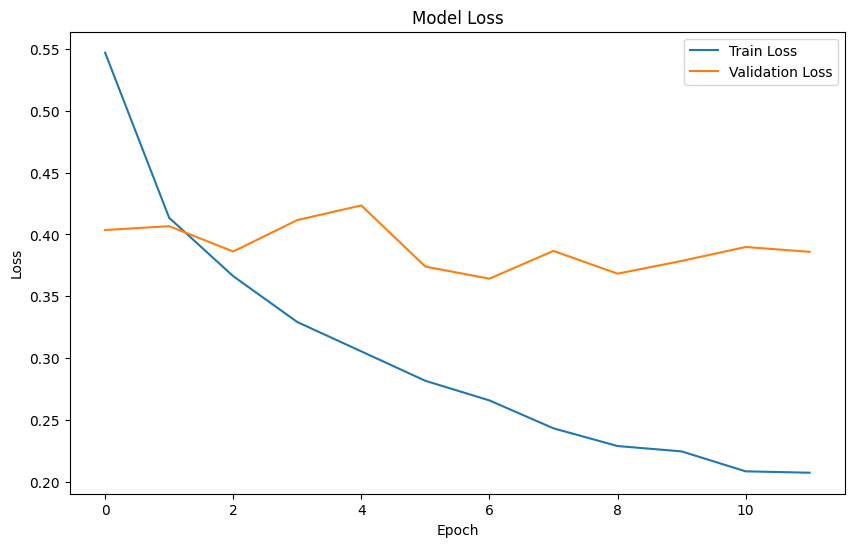

In [48]:
# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()


In [49]:
# Reconstruction errors on training data
X_train_pred = autoencoder.predict(X_train_seq)
train_losses = np.mean(np.abs(X_train_pred - X_train_seq), axis=(1,2))

# Reconstruction errors on validation data
X_val_pred = autoencoder.predict(X_val_seq)
val_losses = np.mean(np.abs(X_val_pred - X_val_seq), axis=(1,2))


5508/5508 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step
1739/1739 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


In [50]:
mean_train_loss = np.mean(train_losses)
std_train_loss = np.std(train_losses)

# First threshold for severe anomalies ('BROKEN')
threshold_broken = mean_train_loss + 4.5 * std_train_loss

# Second threshold for minor anomalies ('RECOVERING')
threshold_recovering = mean_train_loss + 2 * std_train_loss

print(f"Threshold for 'BROKEN': {threshold_broken}")
print(f"Threshold for 'RECOVERING': {threshold_recovering}")


Threshold for 'BROKEN': 0.5570465722320939
Threshold for 'RECOVERING': 0.4179521774205735


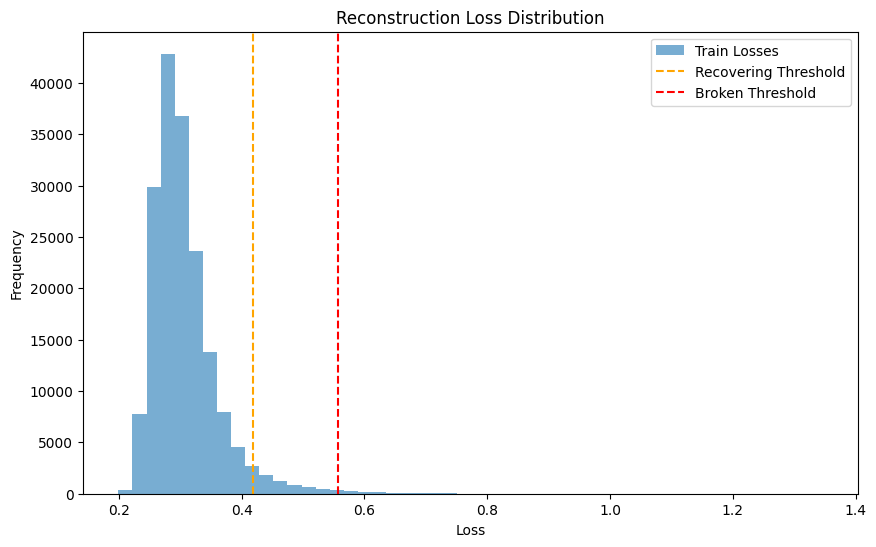

In [51]:
plt.figure(figsize=(10, 6))
plt.hist(train_losses, bins=50, alpha=0.6, label='Train Losses')
plt.axvline(threshold_recovering, color='orange', linestyle='--', label='Recovering Threshold')
plt.axvline(threshold_broken, color='red', linestyle='--', label='Broken Threshold')
plt.title('Reconstruction Loss Distribution')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [52]:
# Initialize predictions array
val_preds = np.zeros(len(val_losses))

# Assign labels based on thresholds
for i, loss in enumerate(val_losses):
    if loss > threshold_broken:
        val_preds[i] = 2  # 'BROKEN'
    elif loss > threshold_recovering and loss < threshold_broken :
        val_preds[i] = 1  # 'RECOVERING'
    else:
        val_preds[i] = 0  # 'NORMAL'


In [53]:
from sklearn.metrics import classification_report, confusion_matrix

# Mapping numerical labels back to status names for report
target_names = ['NORMAL', 'RECOVERING', 'BROKEN']

print("\nClassification Report:")
print(classification_report(y_val_labels, val_preds.astype(int), target_names=target_names, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_val_labels, val_preds.astype(int)))



Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      0.82      0.90     41159
  RECOVERING       0.00      0.00      0.00         7
      BROKEN       0.90      1.00      0.95     14477

    accuracy                           0.87     55643
   macro avg       0.63      0.61      0.62     55643
weighted avg       0.97      0.87      0.91     55643

Confusion Matrix:
[[33920  5582  1657]
 [    0     0     7]
 [    0     0 14477]]


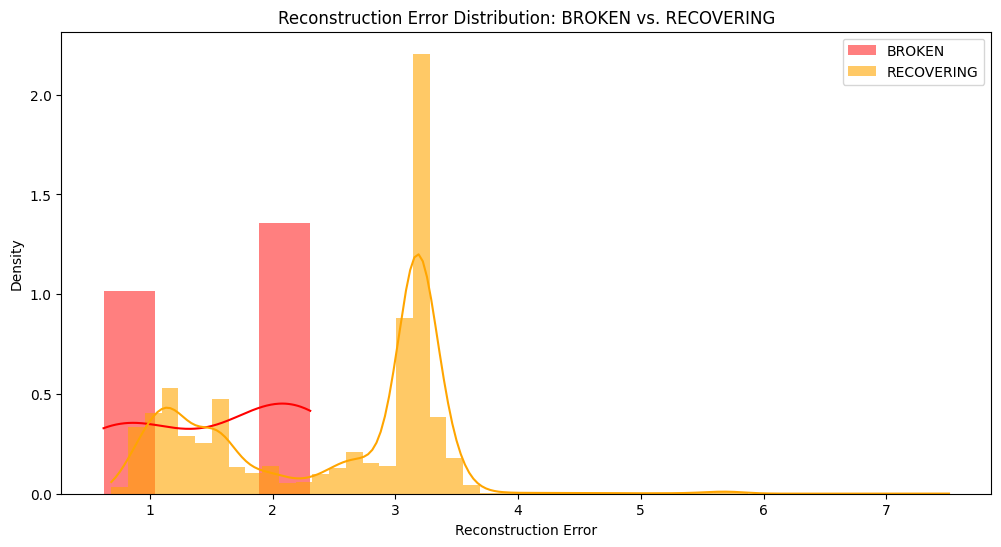

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have already calculated val_losses and have y_val_labels
# y_val_labels contains 0 (NORMAL), 1 (BROKEN), 2 (RECOVERING)

# Create a DataFrame for easy plotting
error_df = pd.DataFrame({
    'Reconstruction_Error': val_losses,
    'Machine_Status': y_val_labels
})

# Map numeric labels to status names for clarity
status_mapping = {0: 'NORMAL', 1: 'BROKEN', 2: 'RECOVERING'}
error_df['Status'] = error_df['Machine_Status'].map(status_mapping)

# Separate the data
broken_errors = error_df[error_df['Status'] == 'BROKEN']['Reconstruction_Error']
recovering_errors = error_df[error_df['Status'] == 'RECOVERING']['Reconstruction_Error']

# Plotting
plt.figure(figsize=(12, 6))
sns.histplot(broken_errors, color='red', label='BROKEN', kde=True, stat="density", linewidth=0)
sns.histplot(recovering_errors, color='orange', label='RECOVERING', kde=True, stat="density", linewidth=0, alpha=0.6)
plt.title('Reconstruction Error Distribution: BROKEN vs. RECOVERING')
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.legend()
plt.show()


C:\Users\mozah\AppData\Local\Temp\ipykernel_21044\2583123639.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y='Reconstruction_Error', data=error_df, palette=['green', 'red', 'orange'])


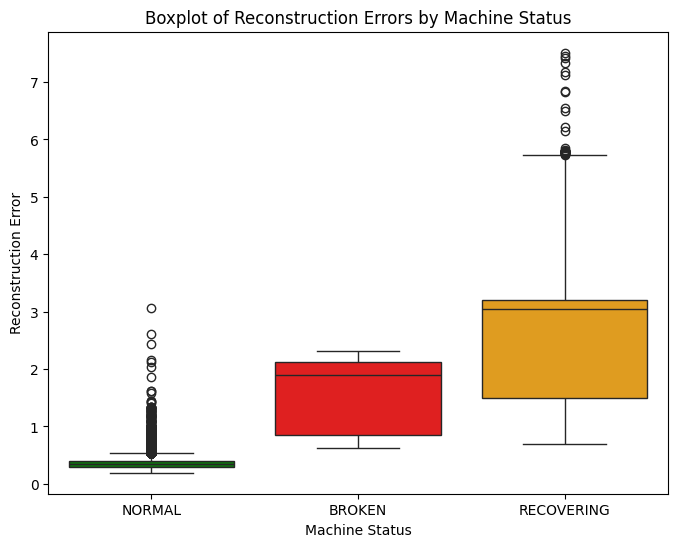

In [55]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Status', y='Reconstruction_Error', data=error_df, palette=['green', 'red', 'orange'])
plt.title('Boxplot of Reconstruction Errors by Machine Status')
plt.xlabel('Machine Status')
plt.ylabel('Reconstruction Error')
plt.show()


# LSTM for prediction

In [56]:
df.head()

,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_47,sensor_48,sensor_49,sensor_51,machine_status,hour,day_of_week,month,reconstruction_error,anomaly
0,2018-04-01 00:00:00,0.316593,-0.153017,0.639354,1.057648,0.303460,0.177146,0.069626,0.204869,0.235627,...,-0.588576,0.086321,0.553118,-0.248497,0,0,6,4,NaN,False
1,2018-04-01 00:01:00,0.316593,-0.153017,0.639354,1.057648,0.303460,0.177146,0.069626,0.204869,0.235627,...,-0.588576,0.086321,0.553118,-0.248497,0,0,6,4,NaN,False
2,2018-04-01 00:02:00,0.282302,-0.074142,0.639354,1.093535,0.334798,0.008730,0.039723,0.175485,0.252534,...,-0.588576,0.061693,0.522888,-0.238384,0,0,6,4,NaN,False
3,2018-04-01 00:03:00,0.308427,-0.153017,0.627520,1.093535,0.260070,0.207736,0.037233,0.241039,0.279100,...,-0.588576,0.061693,0.507773,-0.240912,0,0,6,4,NaN,False
4,2018-04-01 00:04:00,0.283935,-0.139872,0.639354,1.093535,0.317924,0.184615,0.049692,0.229736,0.279100,...,-0.533155,0.089840,0.492658,-0.248497,0,0,6,4,NaN,False


In [57]:
sensor_cols = [col for col in df.columns if 'sensor_' in col]
df[sensor_cols].head()

,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,...,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_51
0,0.316593,-0.153017,0.639354,1.057648,0.303460,0.177146,0.069626,0.204869,0.235627,0.190016,...,-0.553933,-0.358935,-0.176764,-0.260476,1.759656,0.185925,-0.588576,0.086321,0.553118,-0.248497
1,0.316593,-0.153017,0.639354,1.057648,0.303460,0.177146,0.069626,0.204869,0.235627,0.190016,...,-0.553933,-0.358935,-0.176764,-0.260476,1.759656,0.185925,-0.588576,0.086321,0.553118,-0.248497
2,0.282302,-0.074142,0.639354,1.093535,0.334798,0.008730,0.039723,0.175485,0.252534,0.175335,...,-0.619875,-0.358935,-0.200344,-0.285471,1.737116,0.204425,-0.588576,0.061693,0.522888,-0.238384
3,0.308427,-0.153017,0.627520,1.093535,0.260070,0.207736,0.037233,0.241039,0.279100,0.199806,...,-0.619875,-0.384319,-0.271084,-0.310468,1.692034,0.204425,-0.588576,0.061693,0.507773,-0.240912
4,0.283935,-0.139872,0.639354,1.093535,0.317924,0.184615,0.049692,0.229736,0.279100,0.199806,...,-0.553933,-0.384319,-0.223923,-0.335464,1.714575,0.241425,-0.533155,0.089840,0.492658,-0.248497


In [58]:
import numpy as np
import pandas as pd
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt


In [59]:

label_col = 'machine_status'

# Extract features and labels
data = df[sensor_cols].values  # Shape: (num_samples, num_features)
labels = df[label_col].values  # Shape: (num_samples,)

# Relabel to combine BROKEN and RECOVERING into ANOMALY
labels_binary = np.where(labels == 0, 0, 1)  # 0: NORMAL, 1: ANOMALY


In [60]:
def create_sequences_for_future_prediction(data, labels, seq_length, prediction_horizon):
    X = []
    y = []
    for i in range(len(data) - seq_length - prediction_horizon + 1):
        X_seq = data[i:i+seq_length]
        future_labels = labels[i+seq_length:i+seq_length+prediction_horizon]
        y_label = 1 if 1 in future_labels else 0
        X.append(X_seq)
        y.append(y_label)
    return np.array(X), np.array(y)

sequence_length = 60  # Past 60 time steps
prediction_horizon = 5  # Predict anomalies within the next 5 time steps

X, y = create_sequences_for_future_prediction(data, labels_binary, sequence_length, prediction_horizon)

# Ensure labels are float32
y = y.astype('float32')



In [62]:
# Split the data chronologically
split_ratio = 0.5
split_index = int(len(X) * split_ratio)

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]


In [63]:
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))


In [64]:
def f1_score_metric(y_true, y_pred):
    y_true = K.cast(y_true, 'float32')
    y_pred_binary = K.round(y_pred)

    tp = K.sum(y_true * y_pred_binary)
    fp = K.sum((1 - y_true) * y_pred_binary)
    fn = K.sum(y_true * (1 - y_pred_binary))

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())

    f1 = 2 * ((precision * recall) / (precision + recall + K.epsilon()))
    return f1

In [65]:
n_features = X_train.shape[2]  # Number of sensor readings

from tensorflow.keras.layers import Dropout

# Example of adding dropout
inputs = Input(shape=(sequence_length, n_features))
x = LSTM(64, activation='relu', return_sequences=True)(inputs)
x = Dropout(0.5)(x)
x = LSTM(32, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs, outputs)



# Compile the model with appropriate loss and metrics
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[Precision(name='precision'), Recall(name='recall'), f1_score_metric]
)

In [66]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,  # Apply class weights
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
3442/3442 ━━━━━━━━━━━━━━━━━━━━ 153s 43ms/step - f1_score_metric: 0.0776 - loss: 262.4790 - precision: 0.2357 - recall: 0.8641 - val_f1_score_metric: 0.0717 - val_loss: 0.9425 - val_precision: 0.7358 - val_recall: 0.9225
Epoch 2/30
3442/3442 ━━━━━━━━━━━━━━━━━━━━ 140s 41ms/step - f1_score_metric: 0.0644 - loss: 1.9212 - precision: 0.5092 - recall: 0.9377 - val_f1_score_metric: 0.0762 - val_loss: 0.8176 - val_precision: 0.5477 - val_recall: 0.9802
Epoch 3/30
3442/3442 ━━━━━━━━━━━━━━━━━━━━ 129s 37ms/step - f1_score_metric: 0.0594 - loss: 0.4119 - precision: 0.7040 - recall: 0.9604 - val_f1_score_metric: 0.0719 - val_loss: 0.3500 - val_precision: 0.6613 - val_recall: 0.9152
Epoch 4/30
3442/3442 ━━━━━━━━━━━━━━━━━━━━ 116s 34ms/step - f1_score_metric: 0.0587 - loss: 0.1664 - precision: 0.7527 - recall: 0.9760 - val_f1_score_metric: 0.0654 - val_loss: 0.3691 - val_precision: 0.6686 - val_recall: 0.8339
Epoch 5/30
3442/3442 ━━━━━━━━━━━━━━━━━━━━ 115s 33ms/step - f1_score_metric: 0.0587

In [67]:
# Predict probabilities
y_pred_prob = model.predict(X_val)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob > 0.9).astype(int).reshape(-1)

3442/3442 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step


In [68]:
# Classification Report
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=['NORMAL', 'ANOMALY']))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

# ROC AUC Score
auc = roc_auc_score(y_val, y_pred_prob)
print(f"ROC AUC Score: {auc:.2f}")

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.99      1.00      0.99    101607
     ANOMALY       0.94      0.84      0.89      8521

    accuracy                           0.98    110128
   macro avg       0.96      0.92      0.94    110128
weighted avg       0.98      0.98      0.98    110128

Confusion Matrix:
[[101125    482]
 [  1334   7187]]
ROC AUC Score: 1.00


In [69]:
len(y_pred)


110128

# Precision
NORMAL (Class 0): 1.0
0
Interpretation: When the model predicts a data point as NORMAL, it is 100% correct. There are no false positives for this clas
s.
ANOMALY (Class 1): 0.78
Interpretation: When the model predicts a data point as ANOMALY, it is 78% correct. This means that 22% of the predictions for ANOMALY are false positives (i.e., NORMAL instances incorrectly classified as ANOMALon and recall.

#  Recall
NORMAL (Class 0): 0.98
Interpretation: The model correctly identifies 98% of all actual NORMAL instances. Only 2% of NORMAL instances are missed (i.e., incorrectly classified as ANOMALY).
ANOMALY (Class 1): 0.96
Interpretation: The model correctly identifies 96% of all actual ANOMALY instances. Only 4% of ANOMALY instances are missed (i.e., incorrectly classified as NORMAL).


# F1-Score
NORMAL (Class 0): 0.99
Interpretation: The F1-Score, which balances precision and recall, is 0.99 for NORMAL, indicating excellent performance.
ANOMALY (Class 1): 0.86
Interpretation: The F1-Score for ANOMALY is 0.86, reflecting a strong balance between precision and recall.

In [70]:

# Define sequence parameters
sequence_length = 60
prediction_horizon = 5

# Calculate validation sequence end indices
val_size = len(y_val)  # 44,052
val_start_seq = split_index  # 176,205
val_end_seq = split_index + val_size  # 176,205 + 44,052 = 220,257

# Calculate DataFrame indices corresponding to validation set
sequence_end_indices_val = np.arange(val_start_seq, val_end_seq) + sequence_length + prediction_horizon - 1  # 176,205 to 220,257 +64 = 176,269 to 220,321

# Ensure indices are within DataFrame bounds
sequence_end_indices_val = sequence_end_indices_val[sequence_end_indices_val < len(df)]

print(f"Validation Sequence End Indices: {sequence_end_indices_val[:5]}")
# Ensure 'timestamp' is in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract corresponding timestamps for validation set
timestamps_val = df['timestamp'].iloc[sequence_end_indices_val].values

# Verify alignment
print(f"Length of timestamps_val: {len(timestamps_val)}")  # Should be 44,052
print(f"Length of y_val: {len(y_val)}")                    # Should be 44,052


Validation Sequence End Indices: [110192 110193 110194 110195 110196]
Length of timestamps_val: 110128
Length of y_val: 110128


In [71]:

# Define your sequence parameters
sequence_length = 60
prediction_horizon = 5

# Calculate the DataFrame indices corresponding to the end of each validation sequence
sequence_end_indices_val = np.arange(split_index, split_index + len(y_val)) + sequence_length + prediction_horizon - 1

# Ensure indices are within DataFrame bounds
sequence_end_indices_val = sequence_end_indices_val[sequence_end_indices_val < len(df)]

# Extract corresponding timestamps
df['timestamp'] = pd.to_datetime(df['timestamp'])  # Ensure 'timestamp' is in datetime format
timestamps_val = df['timestamp'].iloc[sequence_end_indices_val].values

# Verify alignment
print(f"Length of timestamps_val: {len(timestamps_val)}")  # Should match len(y_val)
print(f"Length of y_val: {len(y_val)}")                    # 44,051


Length of timestamps_val: 110128
Length of y_val: 110128


In [72]:
sequence_end_indices_val = sequence_end_indices_val[:len(y_val)]

In [73]:
# Define parameters for warning system
consecutive_predictions_required = 3  # Number of consecutive predictions to trigger a warning

# Initialize warnings list
warnings = ['No Warning'] * len(y_val)

# Generate warnings based on consecutive predictions and machine_status
for i in range(len(y_val) - consecutive_predictions_required + 1):
    window = y_val[i:i + consecutive_predictions_required]
    if all(pred == 1 for pred in window):
        # Get the corresponding DataFrame index for the last prediction in the window
        df_index = sequence_end_indices_val[i + consecutive_predictions_required - 1]
        machine_status = df.loc[df_index, 'machine_status']
        if machine_status != 0:
            timestamp = df.loc[df_index, 'timestamp']
            warnings[i + consecutive_predictions_required - 1] = f'Warning: Anomaly Likely at {timestamp}'

# Add warnings to the DataFrame for visualization
# Initialize 'warning' column as 'No Warning' if not already present
if 'warning' not in df.columns:
    df['warning'] = 'No Warning'

# Assign warnings to the corresponding validation indices
df.loc[sequence_end_indices_val, 'warning'] = warnings

# Display the warnings for the first few validation sequences
print(df[['timestamp', 'machine_status', 'warning']].iloc[sequence_end_indices_val].head())

                 timestamp  machine_status     warning
110192 2018-06-16 12:32:00               0  No Warning
110193 2018-06-16 12:33:00               0  No Warning
110194 2018-06-16 12:34:00               0  No Warning
110195 2018-06-16 12:35:00               0  No Warning
110196 2018-06-16 12:36:00               0  No Warning


In [74]:
df['warning'].value_counts()

warning
No Warning                                        211817
                                                   ...  
Name: count, Length: 8504, dtype: int64

In [75]:
# Define parameters for warning system
consecutive_predictions_required = 3  # Number of consecutive predictions to trigger a warning

# Initialize warnings list
warnings = ['No Warning'] * len(y_val)

# Generate warnings based on consecutive predictions
for i in range(len(y_val) - consecutive_predictions_required + 1):
    window = y_val[i:i + consecutive_predictions_required]
    if all(pred == 1 for pred in window):
        warnings[i + consecutive_predictions_required - 1] = 'Warning: Anomaly Likely'

# Add warnings to the DataFrame for visualization
# Initialize 'warning' column as 'No Warning' if not already present
if 'warning' not in df.columns:
    df['warning'] = 'No Warning'

# Assign 'Warning: Anomaly Likely' to the corresponding validation indices
df.loc[sequence_end_indices_val, 'warning'] = warnings

# Display the warnings for the first few validation sequences
print(df[['timestamp', 'machine_status', 'warning']].iloc[sequence_end_indices_val].head())


                 timestamp  machine_status     warning
110192 2018-06-16 12:32:00               0  No Warning
110193 2018-06-16 12:33:00               0  No Warning
110194 2018-06-16 12:34:00               0  No Warning
110195 2018-06-16 12:35:00               0  No Warning
110196 2018-06-16 12:36:00               0  No Warning


In [76]:
df['warning'].value_counts()

warning
No Warning                 211805
Name: count, dtype: int64

In [77]:
# Doğrulama seti DataFrame'i oluştur
df_val = df.iloc[sequence_end_indices_val].copy()

# Etiketleri ekle
df_val['actual_label'] = y_val
df_val['predicted_label'] = y_pred

# 'machine_status' değeri 1 olanları filtrele
df_anomalies = df_val[df_val['machine_status'] != 0]

# Modelin doğru tahmin edip etmediğini kontrol et
df_anomalies['prediction_correct'] = df_anomalies['predicted_label'] == 1

# İlk birkaç sonucu görüntüle
print(df_anomalies[['timestamp', 'machine_status', 'predicted_label', 'prediction_correct']].head())

# Özet istatistikler
num_actual_anomalies = df_anomalies.shape[0]
num_detected_anomalies = df_anomalies['prediction_correct'].sum()
detection_rate = (num_detected_anomalies / num_actual_anomalies) * 100 if num_actual_anomalies > 0 else 0

print(f"Total actual anomalies: {num_actual_anomalies}")
print(f"Total detected anomalies: {num_detected_anomalies}")
print(f"Detection Rate: {detection_rate:.2f}%")


                 timestamp  machine_status  predicted_label  \
128040 2018-06-28 22:00:00               1                0   
128041 2018-06-28 22:01:00               2                0   
128042 2018-06-28 22:02:00               2                0   
128043 2018-06-28 22:03:00               2                0   
128044 2018-06-28 22:04:00               2                0   

        prediction_correct  
128040               False  
128041               False  
128042               False  
128043               False  
128044               False  
Total actual anomalies: 8509
Total detected anomalies: 7179
Detection Rate: 84.37%


C:\Users\mozah\AppData\Local\Temp\ipykernel_21044\3017041507.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anomalies['prediction_correct'] = df_anomalies['predicted_label'] == 1


In [78]:
# Parameters
consecutive_predictions_required = 2  # Number of consecutive predictions to trigger a warning

# Initialize warnings list
warnings = ['No Warning'] * len(y_pred)

# Generate warnings based on predictions
for i in range(len(y_pred) - consecutive_predictions_required + 1):
    window = y_pred[i:i+consecutive_predictions_required]
    if all(pred == 1 for pred in window):
        warnings[i + consecutive_predictions_required - 1] = 'Warning: Anomaly Likely'

# Print the warnings for each time step
for idx, warning in enumerate(warnings):
    if warning == 'Warning: Anomaly Likely':
        print(f"Time Step {idx}: {warning}")

Time Step 18025: Warning: Anomaly Likely
Time Step 18026: Warning: Anomaly Likely
Time Step 18027: Warning: Anomaly Likely
Time Step 18028: Warning: Anomaly Likely
Time Step 18029: Warning: Anomaly Likely
Time Step 18030: Warning: Anomaly Likely
Time Step 18035: Warning: Anomaly Likely
Time Step 18036: Warning: Anomaly Likely
Time Step 18037: Warning: Anomaly Likely
Time Step 18038: Warning: Anomaly Likely
Time Step 18039: Warning: Anomaly Likely
Time Step 18040: Warning: Anomaly Likely
Time Step 18041: Warning: Anomaly Likely
Time Step 18042: Warning: Anomaly Likely
Time Step 18043: Warning: Anomaly Likely
Time Step 18044: Warning: Anomaly Likely
Time Step 18045: Warning: Anomaly Likely
Time Step 18046: Warning: Anomaly Likely
Time Step 18047: Warning: Anomaly Likely
Time Step 18048: Warning: Anomaly Likely
Time Step 18049: Warning: Anomaly Likely
Time Step 18050: Warning: Anomaly Likely
Time Step 18051: Warning: Anomaly Likely
Time Step 18052: Warning: Anomaly Likely
Time Step 18053:

C:\Users\mozah\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


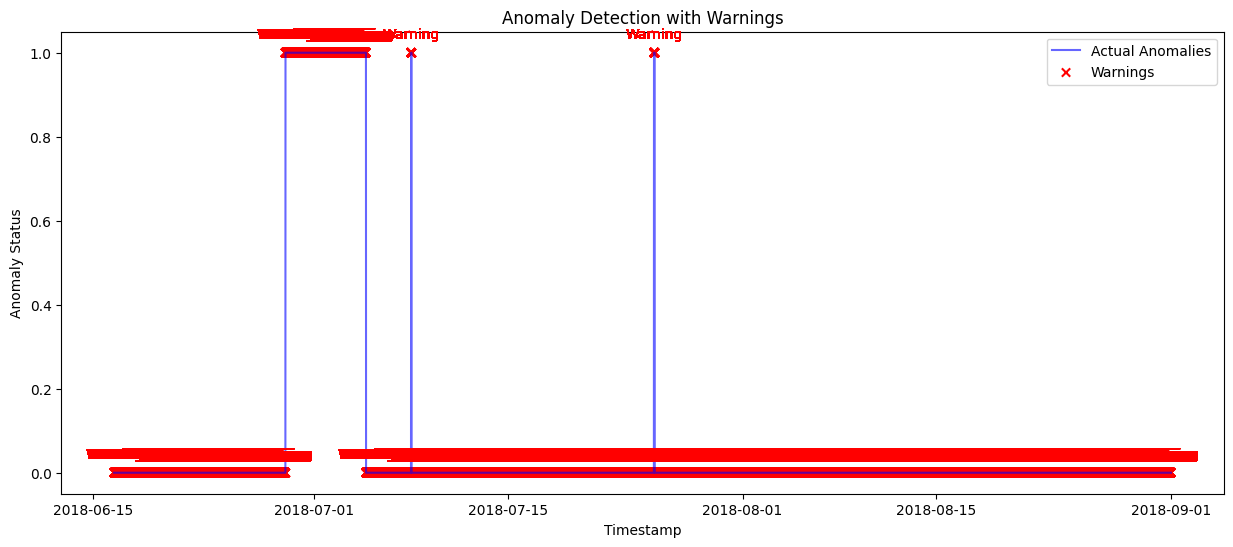

In [79]:
import matplotlib.pyplot as plt

# Görselleştirme
plt.figure(figsize=(15,6))
plt.plot(timestamps_val, y_val, label='Actual Anomalies', color='blue', alpha=0.6)

# Uyarıları renklendir
warning_colors = {'No Warning': 'grey', 'Warning: Anomaly Likely at': 'red'}
warning_colors_mapped = ['red' if 'Warning' in warn else 'grey' for warn in warnings]

# Uyarıları işaretle
plt.scatter(timestamps_val, y_val, c=warning_colors_mapped, marker='x', label='Warnings')

# İsteğe bağlı: Uyarıları anotasyonla işaretle
for i, warn in enumerate(warnings):
    if 'Warning' in warn:
        plt.annotate('Warning', (timestamps_val[i], y_val[i]),
                     textcoords="offset points", xytext=(0,10), ha='center', color='red')

plt.title('Anomaly Detection with Warnings')
plt.xlabel('Timestamp')
plt.ylabel('Anomaly Status')
plt.legend(['Actual Anomalies', 'Warnings'])
plt.show()


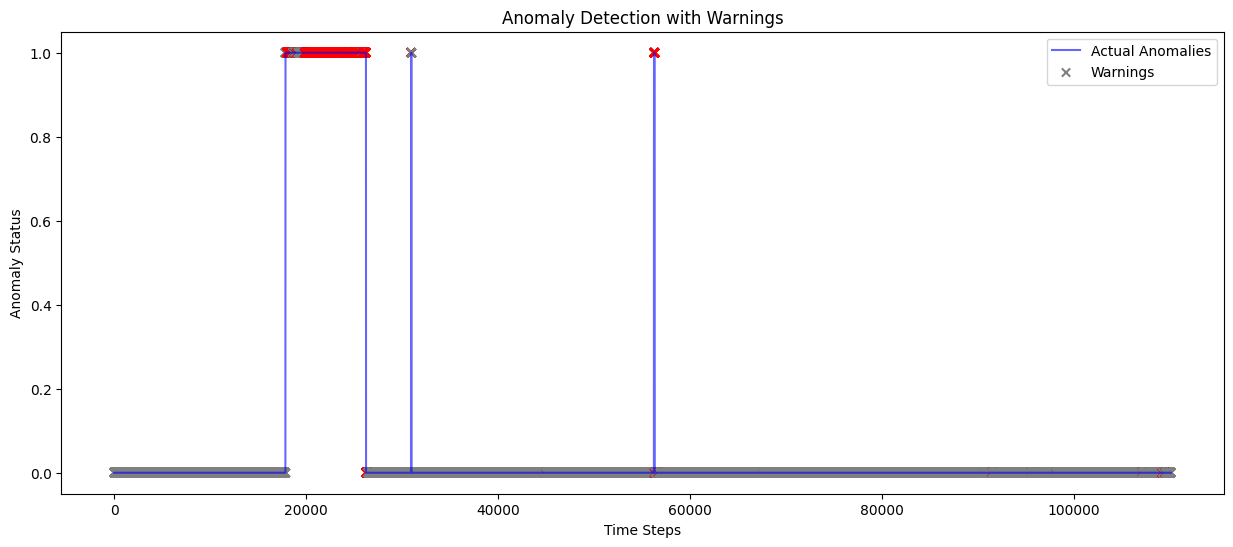

In [80]:
# Visualize warnings alongside actual anomalies
plt.figure(figsize=(15,6))
plt.plot(y_val, label='Actual Anomalies', color='blue', alpha=0.6)

# Map warnings to colors
warning_colors = {'No Warning': 'grey', 'Warning: Anomaly Likely': 'red'}
warning_colors_mapped = [warning_colors[warn] for warn in warnings]

# Plot warnings
plt.scatter(range(len(warnings)), y_val, c=warning_colors_mapped, marker='x', label='Warnings')

plt.title('Anomaly Detection with Warnings')
plt.xlabel('Time Steps')
plt.ylabel('Anomaly Status')
plt.legend(['Actual Anomalies', 'Warnings'])
plt.show()
